In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [9]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [10]:
import math
def plot_all_histograms(df, title_prefix= ""):
    numeric_cols = df.select_dtypes(include= [np.number]).columns
    n_cols= 3
    n_rows= math.ceil(len(numeric_cols) / n_cols) #yukarı yuvarlama

    plt.figure(figsize= (4 * n_cols, 3 * n_rows))

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde= True, bins= 30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")
    plt.tight_layout()
    plt.show()

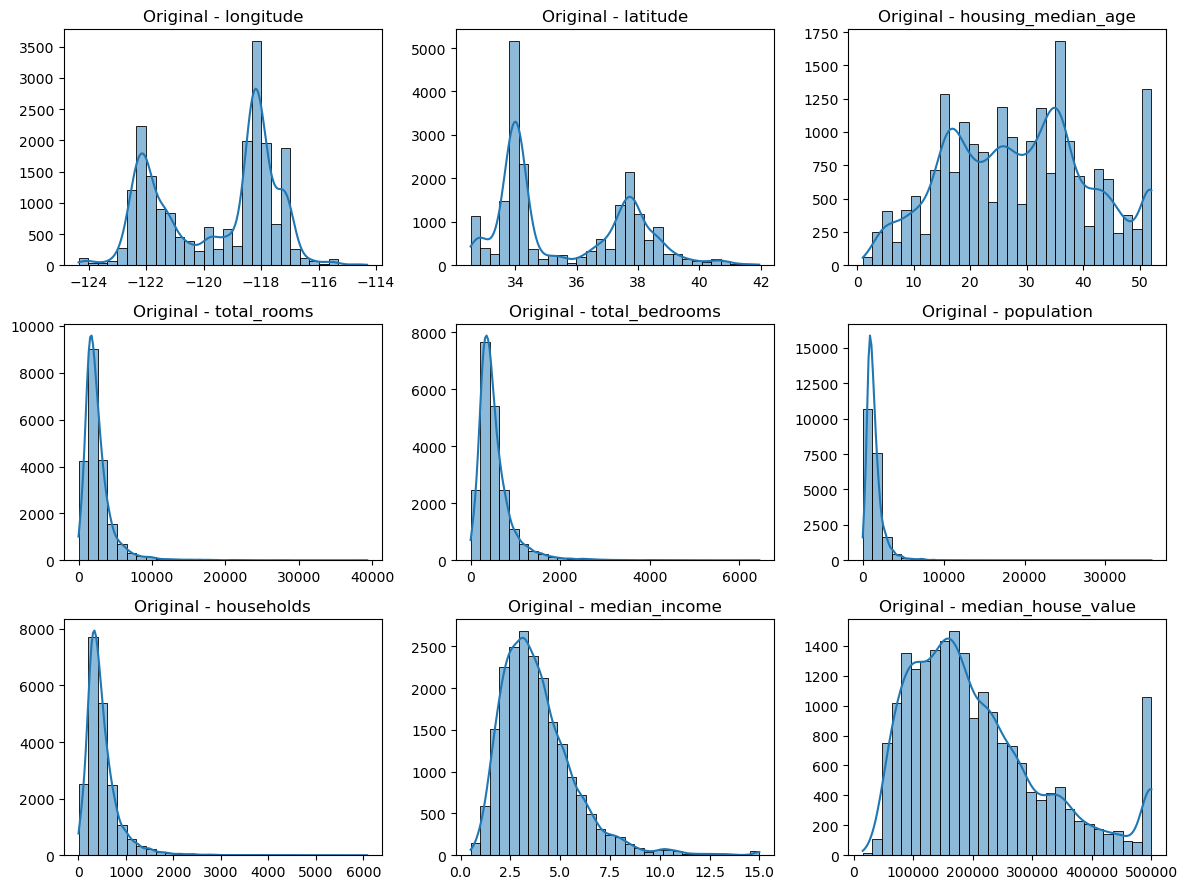

In [11]:
plot_all_histograms(df, title_prefix= "Original -")

In [12]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [13]:
df = pd.get_dummies(df, columns= ["ocean_proximity"], drop_first= True)

In [14]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  bool   
 10  ocean_proximity_ISLAND      20640 non-null  bool   
 11  ocean_proximity_NEAR BAY    20640 non-null  bool   
 12  ocean_proximity_NEAR OCEAN  20640 non-null  bool   
dtypes: bool(4), float64(9)
memory u

In [16]:
from scipy.stats import skew

In [17]:
df.apply(skew)

longitude                     -0.297780
latitude                       0.465919
housing_median_age             0.060326
total_rooms                    4.147042
total_bedrooms                 3.480888
population                     4.935500
households                     3.410190
median_income                  1.646537
median_house_value             0.977692
ocean_proximity_INLAND         0.784625
ocean_proximity_ISLAND        64.226165
ocean_proximity_NEAR BAY       2.477478
ocean_proximity_NEAR OCEAN     2.216540
dtype: float64

In [18]:
X = df.drop("median_house_value", axis= 1)
y = df["median_house_value"]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 15)

In [21]:
from sklearn.preprocessing import PowerTransformer

In [22]:
pt_X = PowerTransformer(method= "yeo-johnson")
X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [23]:
column_names_X = ['longitude', 'latitude', 'housing_median_age', 'total_rooms','total_bedrooms', 
                  'population', 'households', 'median_income', "ocean_proximity_INLAND", 
                  'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

In [24]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=column_names_X)

In [25]:
X_train_transformed

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,4.996004e-16,-0.589877,-0.822604,-1.140506,-1.477185,-1.824702,-1.666182,1.235060,-0.684319,-0.018606,-0.353264,-0.384988
1,-1.137979e-15,1.298467,-0.994540,1.086494,1.487045,0.377584,1.341423,-0.161987,1.461306,-0.018606,-0.353264,-0.384988
2,-1.471046e-15,1.210360,-1.350903,0.862216,0.888510,0.896949,1.032678,0.110539,1.461306,-0.018606,-0.353264,-0.384988
3,-9.714451e-16,1.644850,-0.994540,0.215611,0.320797,-0.837955,-0.747506,-0.979127,1.461306,-0.018606,-0.353264,-0.384988
4,-1.165734e-15,1.286556,0.678908,0.333763,0.404283,0.445304,0.420656,-1.395898,1.461306,-0.018606,-0.353264,-0.384988
...,...,...,...,...,...,...,...,...,...,...,...,...
14443,-1.054712e-15,1.114782,1.119140,-1.007000,-1.078167,-1.149793,-1.173937,-0.572532,1.461306,-0.018606,-0.353264,-0.384988
14444,2.831069e-15,-1.632460,-0.994540,-0.859240,-1.102590,-1.176003,-1.088203,1.280032,1.461306,-0.018606,-0.353264,-0.384988
14445,8.049117e-16,-0.846440,0.147843,0.041350,0.306998,-0.205976,0.397916,0.056970,-0.684319,-0.018606,-0.353264,2.597483
14446,1.387779e-16,-0.559086,0.378002,0.176498,-0.251296,-0.179182,-0.214564,0.666439,-0.684319,-0.018606,-0.353264,2.597483


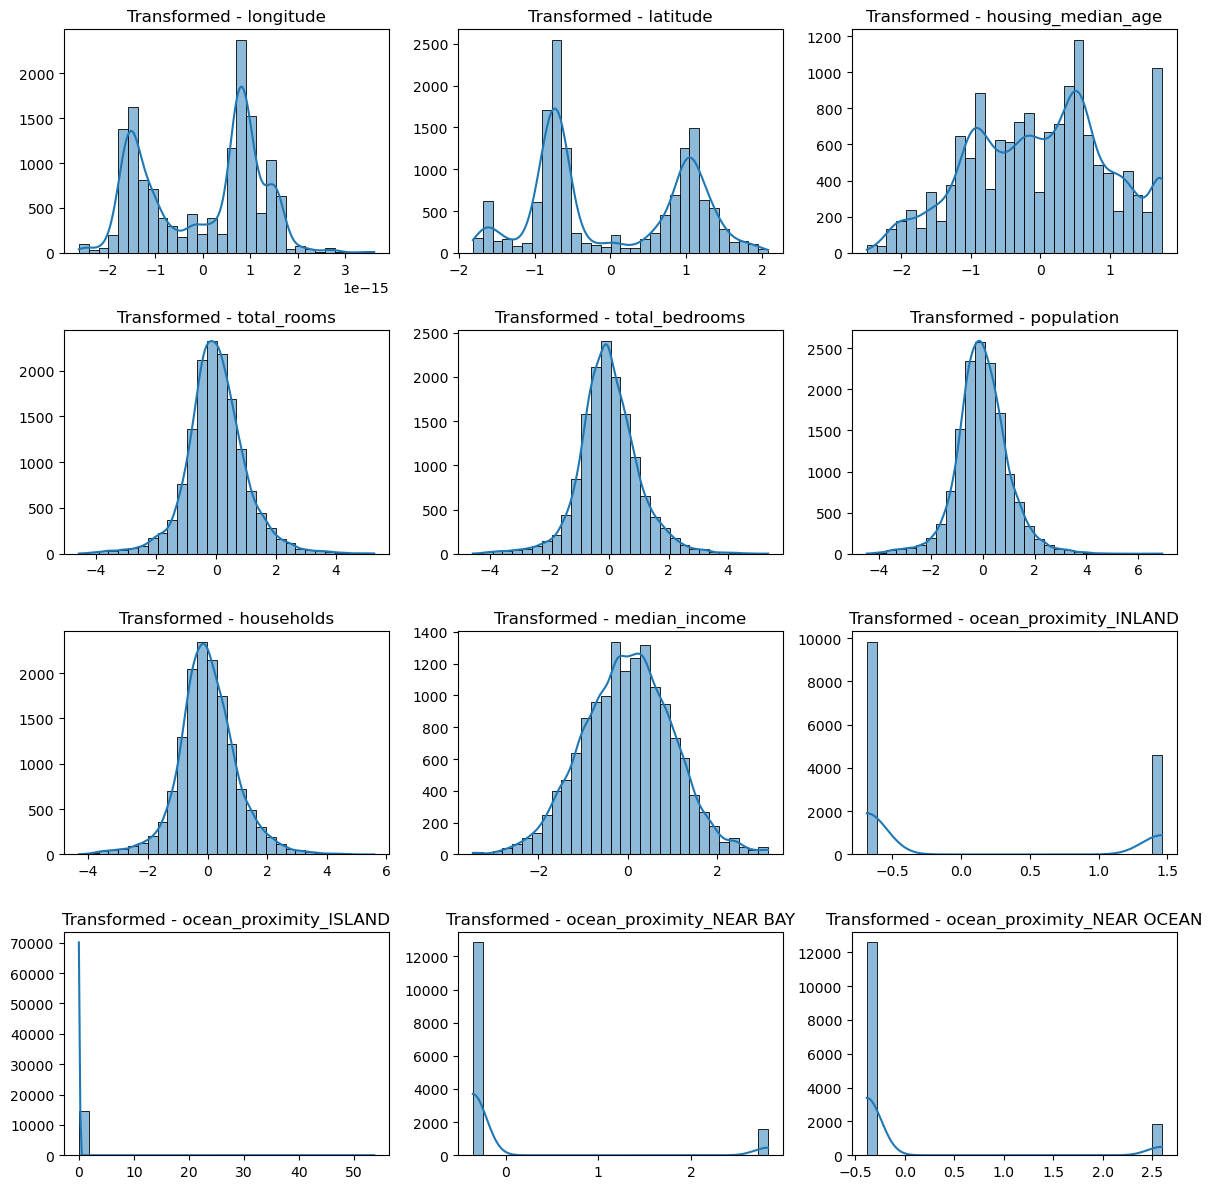

In [26]:
plot_all_histograms(X_train_transformed, title_prefix= "Transformed -")

In [27]:
from scipy.stats import boxcox

In [28]:
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y) 
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [29]:
y_train_transformed, lambda_y = boxcox(y_train)

In [30]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import r2_score, mean_absolute_error

In [31]:
models = {
    "XGBoost Regressor" : XGBRegressor(),
    "LightGBM Regressor": LGBMRegressor()
}

In [42]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_transformed, y_train_transformed)

    y_test_pred = model.predict(X_test_transformed)
    y_test_pred_original = inverse_boxcox(y_test_pred, lambda_y)

    print(list(models.keys())[i])
    print("-----------------------------------")
    print("Model performance for Test Set")
    print("Mean Absolute Error: ", mean_absolute_error(y_test, y_test_pred_original))
    print("R2 Score: ", r2_score(y_test, y_test_pred_original))
    print("-----------------------------------")

XGBoost Regressor
-----------------------------------
Model performance for Test Set
Mean Absolute Error:  31392.30267302685
R2 Score:  0.8250201342554252
-----------------------------------
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1781
[LightGBM] [Info] Number of data points in the train set: 14448, number of used features: 11
[LightGBM] [Info] Start training from score 27.921047
LightGBM Regressor
-----------------------------------
Model performance for Test Set
Mean Absolute Error:  31708.31315647159
R2 Score:  0.8266737959128431
-----------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [33]:
#hyperparameter tuning 

In [34]:
xgboost_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.1, 0.01],
    "max_depth": [5,8,12,20,30],
    "colsample_bytree" : [0.3, 0.4, 0.5, 0.7, 1]
}

In [35]:
from sklearn.model_selection import RandomizedSearchCV

In [37]:
random_search = RandomizedSearchCV(estimator= XGBRegressor(), param_distributions= xgboost_params, cv= 5, n_jobs= -1)

In [38]:
random_search.fit(X_train_transformed, y_train_transformed)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.3, 0.4, ...], 'learning_rate': [0.1, 0.01], 'max_depth': [5, 8, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [41]:
y_test_pred = random_search.predict(X_test_transformed)
y_test_pred_original = inverse_boxcox(y_test_pred, lambda_y)

print("-----------------------------------")
print("Model performance for Test Set")
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_test_pred_original))
print("R2 Score: ", r2_score(y_test, y_test_pred_original))
print("-----------------------------------")

-----------------------------------
Model performance for Test Set
Mean Absolute Error:  30465.04220756416
R2 Score:  0.832173366137825
-----------------------------------
